<a href="https://colab.research.google.com/github/zahira456/2411532015_PrakBigData/blob/main/BD_A_P03_2411532015_Zahira_Nur_Asyifa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-1. Menyiapkan Lingkungan

Pada langkah ini dilakukan persiapan lingkungan Google Colab, pengecekan versi pustaka yang digunakan, pembuatan folder kerja, serta penyiapan fungsi untuk mengukur waktu, penggunaan memori, dan mencatat asal-usul data.


In [14]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



K-2. Akuisisi Data Berkala

Pada langkah ini dilakukan pengunduhan data perjalanan taksi dan tabel zona. Proses unduhan menggunakan retry, caching, dan penulisan atomik agar lebih aman ketika terjadi gangguan jaringan dan saat notebook dijalankan kembali.

In [15]:
import requests, shutil

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()

                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)

                if os.path.getsize(sementara) == 0:
                    raise IOError("berkas kosong")

                os.replace(sementara, tujuan) # atomik
                return tujuan

        except Exception as e:
            jeda = jeda_awal * (2 ** i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")


URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")

PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")


KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA, compression="gzip")

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")

zona.head()

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.0 MB
[baca trip] 0.45 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


K-3. Akuisisi Data dari API JSON

Pada langkah ini dilakukan pengambilan data cuaca per jam dari API Open-Meteo. Respons API diperiksa terlebih dahulu dan permintaan akan diulang untuk beberapa kode error yang bersifat sementara.

In [16]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }

    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)

        if r.status_code == 200:
            data = r.json()

            if "hourly" not in data:    # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")

            return pd.DataFrame(data["hourly"])

        if r.status_code in (429, 500, 502, 503):    # layak dicoba ulang
            time.sleep(2 ** i)
            continue

        r.raise_for_status()   # galat lain: hentikan

    raise RuntimeError("API cuaca tidak merespons dengan benar")


cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))

cuaca["time"] = pd.to_datetime(cuaca["time"])

cuaca = cuaca.rename(columns={
    "time": "jam_mulai",
    "temperature_2m": "suhu_c",
    "precipitation": "hujan_mm"
})

catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")

cuaca.head()

[ambil cuaca] 0.83 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


K-5. Akuisisi Data dari SQLite

Pada langkah ini dibuat basis data SQLite yang mensimulasikan sistem operasional perusahaan. Data kemudian dibaca menggunakan SQL secara bertahap dengan chunksize agar data yang besar tidak langsung dimuat seluruhnya ke memori.

In [17]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})

tarif_referensi.to_sql(
    "tarif_referensi",
    engine,
    if_exists="replace",
    index=False
)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional",
    engine,
    if_exists="replace",
    index=False,
    chunksize=50_000
)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    engine
)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""

ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0

for bagian in pd.read_sql(
    "SELECT trip_distance FROM trip_operasional",
    engine,
    chunksize=50_000
):
    total_baris += len(bagian)

print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql(
    "SELECT * FROM tarif_referensi",
    engine
)

catat_sumber(
    "tarif_referensi",
    PATH_DB,
    len(tarif_referensi),
    "tabel dimensi dari basis data operasional"
)

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


K-6. Profiling Kualitas Data

Pada langkah ini dilakukan pemeriksaan kualitas data melalui beberapa dimensi, yaitu kelengkapan, keunikan, validitas, konsistensi, dan ketepatan waktu. Hasil pemeriksaan digunakan untuk mengetahui masalah yang terdapat pada data sebelum proses pembersihan.

In [18]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)
def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]

        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),"nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)
profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3)
    }
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)

laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


K-7. Penanganan Nilai Hilang

Pada langkah ini dibandingkan beberapa strategi untuk menangani nilai hilang, yaitu membuang baris, menggunakan median, menggunakan modus, dan menggunakan median berdasarkan kelompok jam. Hasil setiap strategi dibandingkan melalui jumlah data dan statistik deskriptif.

In [19]:
KOL = "passenger_count"
asli = trip[KOL]

print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(
        trip.groupby("jam")[KOL].transform("median")
    ),
}
banding = pd.DataFrame([
    {
        "strategi": nama,
        "n": len(s),
        "mean": round(s.mean(), 4),
        "median": s.median(),
        "std": round(s.std(), 4)
    }
    for nama, s in strategi.items()
])
banding

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")

trip[KOL] = trip[KOL].fillna(
    trip.groupby("jam")[KOL].transform("median")
)
trip[KOL] = trip[KOL].fillna(
    trip[KOL].median()
) # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()

KUNCI = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount"
]

dup_kunci = trip.duplicated(subset=KUNCI).sum()

print(
    f"duplikat penuh: {dup_penuh:,} | "
    f"duplikat pada kunci: {dup_kunci:,}"
)

sebelum = len(trip)

trip = trip.drop_duplicates(
    subset=KUNCI,
    keep="first"
).reset_index(drop=True)

print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


K-8. Deteksi Outlier

Pada langkah ini outlier diperiksa menggunakan metode IQR dan Z-score pada beberapa kolom numerik. Kedua metode dibandingkan untuk melihat perbedaan jumlah data yang dianggap sebagai outlier.

In [20]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


def ringkas_outlier(df, kolom):
    hasil = []

    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()

        hasil.append({
            "kolom": kol,
            "batas_bawah": round(lo, 2),
            "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()),
            "p99": round(s.quantile(0.99), 2),
        })

    return pd.DataFrame(hasil)


ringkas_outlier(
    trip,
    ["trip_distance", "durasi_menit", "total_amount"]
)


# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (
    trip["trip_distance"].between(0.01, 100)
    & trip["durasi_menit"].between(1, 180)
    & (trip["total_amount"] > 0)
)

bersih = trip.loc[layak].copy()


# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])

bersih["tarif_ekstrem"] = (
    bersih["total_amount"] > hi
).astype("int8")


# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)

bersih["trip_distance_capped"] = (
    bersih["trip_distance"].clip(upper=batas_atas)
)

print(
    f"{len(trip):,} -> {len(bersih):,} baris "
    f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)"
)


# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique) # WAJIB diperiksa

n0 = len(bersih)

bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
        .rename(columns={
            "Borough": "borough_naik",
            "Zone": "zona_naik"
        }),
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
) # gagal keras bila tidak 1:1

bersih = bersih.drop(columns="LocationID")

print(
    f"baris {n0:,} -> {len(bersih):,} (harus sama)"
)

print(
    "zona tak dikenal:",
    bersih["zona_naik"].isna().sum()
)


# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(
    tarif_referensi[["payment_type", "nama_pembayaran"]],
    on="payment_type",
    how="left",
    validate="many_to_one"
)


# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = (
    bersih["tpep_pickup_datetime"].dt.floor("h")
)

n0 = len(bersih)

bersih = bersih.merge(
    cuaca,
    on="jam_mulai",
    how="left",
    validate="many_to_one"
)

print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


K-9. Rekayasa Fitur

Pada langkah ini dibuat beberapa fitur baru dari data perjalanan, yaitu hari dalam minggu, indikator akhir pekan, kecepatan perjalanan, tarif per mil, dan indikator hujan. Fitur tersebut digunakan untuk menghasilkan data yang lebih siap untuk analisis.

In [80]:
bersih["hari_minggu"] = (
    bersih["tpep_pickup_datetime"].dt.dayofweek
)

bersih["akhir_pekan"] = (
    bersih["hari_minggu"] >= 5
).astype("int8")

bersih["kecepatan_mph"] = (
    bersih["trip_distance"] /
    (bersih["durasi_menit"] / 60)
).round(2)

bersih["tarif_per_mil"] = (
    bersih["total_amount"] /
    bersih["trip_distance"]
).round(3)

bersih["hujan"] = (
    bersih["hujan_mm"].fillna(0) > 0.1
).astype("int8")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = [
    "trip_distance_capped",
    "durasi_menit",
    "suhu_c"
]
FITUR_KAT = [
    "nama_pembayaran",
    "borough_naik"
]
contoh = bersih.dropna(
    subset=FITUR_NUM + FITUR_KAT
).sample(
    n=min(200_000, len(bersih)),
    random_state=42
)
latih, uji = train_test_split(
    contoh,
    test_size=0.2,
    random_state=42
)
skala = StandardScaler().fit(
    latih[FITUR_NUM]
)
latih_num = skala.transform(
    latih[FITUR_NUM]
)
uji_num = skala.transform(
    uji[FITUR_NUM]
) # transform saja, tanpa fit ulang
print(
    "mean latih (harus ~0):",
    latih_num.mean(axis=0).round(3)
)

print(
    "mean uji (tidak harus 0):",
    uji_num.mean(axis=0).round(3)
)
# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)
enc.fit(latih[FITUR_KAT])

latih_kat = enc.transform(
    latih[FITUR_KAT]
)
print(
    "jumlah kolom hasil one-hot:",
    latih_kat.shape[1]
)

print(
    "nama kolom:",
    enc.get_feature_names_out()[:6],
    "..."
)

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


K-10. Pipeline, Validasi, dan Penyimpanan

Pada langkah ini seluruh proses pra-pemrosesan dibungkus menjadi satu pipeline. Sebelum hasil digunakan, data diperiksa menggunakan kontrak skema untuk memastikan kolom, tipe data, jumlah baris, dan keunikan kunci sesuai dengan ketentuan.

In [22]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]",
    "trip_distance": "float64",
    "durasi_menit": "float64",
    "total_amount": "float64",
    "borough_naik": "object",
    "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []

    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(
            tipe.split("[")[0]
        ):
            masalah.append(
                f"tipe {kol}: {df[kol].dtype} != {tipe}"
            )

    if df.empty:
        masalah.append("DataFrame kosong")

    if len(df) != len(
        df.drop_duplicates(subset=KUNCI)
    ):
        masalah.append("masih ada duplikat pada kunci")

    if masalah:
        raise AssertionError(
            "Validasi gagal:\n- " +
            "\n- ".join(masalah)
        )

    print(
        f"Validasi lulus: {len(df):,} baris x "
        f"{df.shape[1]} kolom"
    )

    return df


validasi(bersih)


def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""

    df = pd.read_parquet(
        path_trip,
        columns=KOLOM
    )

    z = pd.read_csv(path_zona, compression="gzip")

    df["durasi_menit"] = (
        (
            df["tpep_dropoff_datetime"] -
            df["tpep_pickup_datetime"]
        ).dt.total_seconds() / 60
    )

    df["jam"] = (
        df["tpep_pickup_datetime"].dt.hour
    )

    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median")
    )
    df = df.drop_duplicates(
        subset=KUNCI
    )
    df = df[
        df["trip_distance"].between(0.01, 100)
        & df["durasi_menit"].between(1, 180)
        & (df["total_amount"] > 0)
    ]
    df = (
        df.merge(
            z[["LocationID", "Borough"]]
            .rename(columns={
                "Borough": "borough_naik"
            }),
            left_on="PULocationID",
            right_on="LocationID",
            how="left",
            validate="many_to_one"
        )
        .drop(columns="LocationID")
        .merge(
            df_tarif[["payment_type", "nama_pembayaran"]],
            on="payment_type",
            how="left",
            validate="many_to_one"
        )
    )

    df["jam_mulai"] = (
        df["tpep_pickup_datetime"].dt.floor("h")
    )
    df = df.merge(
        df_cuaca,
        on="jam_mulai",
        how="left",
        validate="many_to_one"
    )
    return validasi(df)
hasil = ukur(
    "pipeline penuh",
    lambda: pipeline(
        PATH_TRIP,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )
)
OUT = os.path.join(
    DIR_KURASI,
    "trips_bersih"
)
hasil["tanggal"] = (
    hasil["tpep_pickup_datetime"]
    .dt.date
    .astype(str)
)
ukur(
    "tulis parquet berpartisi",
    lambda: hasil.to_parquet(
        OUT,
        partition_cols=["borough_naik"],
        index=False
    )
)
print(
    "partisi yang terbentuk:",
    sorted(os.listdir(OUT))[:5],
    "..."
)
# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(
    PATH_TRIP,
    PATH_ZONA,
    cuaca,
    tarif_referensi
)

print(
    "idempoten?",
    len(ulang) == len(hasil)
)
# Artefak yang dikumpulkan
laporan.to_csv(
    f"{DIR_SIMPAN}/laporan_kualitas.csv",
    index=False
)
pd.DataFrame(lineage).to_csv(
    f"{DIR_SIMPAN}/lineage.csv",
    index=False
)

pd.DataFrame(catatan).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv",
    index=False
)

shutil.make_archive(
    f"{DIR_SIMPAN}/trips_bersih",
    "zip",
    OUT
)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 4.33 s
[tulis parquet berpartisi] 2.50 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

In [23]:
print(laporan.to_string(index=False))

                          aturan   lulus  gagal  persen_gagal
kelengkapan: passenger_count ada 2995023  71743         2.339
      validitas: jarak 0-100 mil 3020816  45950         1.498
 konsistensi: durasi 1-180 menit 3030383  36383         1.186
     validitas: total_amount > 0 3040994  25772         0.840
      konsistensi: total >= fare 3041743  25023         0.816
 ketepatan waktu: dalam Jan 2023 3066718     48         0.002
  keunikan: baris tidak duplikat 3066766      0         0.000
 validitas: PULocationID dikenal 3066766      0         0.000


K-11. Pra-pemrosesan dengan PySpark

Pada langkah ini dilakukan pra-pemrosesan menggunakan PySpark sebagai versi terdistribusi dari proses sebelumnya. Data dibersihkan, digabungkan dengan tabel zona, dihitung jumlah barisnya, lalu disimpan dalam bentuk Parquet berpartisi.

In [56]:
!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-P02")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)

szona = spark.createDataFrame(
    zona[["LocationID", "Borough"]]
)

from pyspark.sql.functions import col, unix_timestamp

sbersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            unix_timestamp("tpep_dropoff_datetime")
            - unix_timestamp("tpep_pickup_datetime")
        ) / 60
    )
    .filter(
        col("trip_distance").between(0.01, 100)
        & col("durasi_menit").between(1, 180)
        & (col("total_amount") > 0)
    )
    .dropDuplicates([
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "total_amount"
    ])
    .join(
        F.broadcast(szona),
        sdf.PULocationID == szona.LocationID,
        "left"
    )
    .drop("LocationID")
)

ukur(
    "spark: hitung baris bersih",
    lambda: sbersih.count()
)

sbersih.groupBy(
    "Borough"
).count().orderBy(
    F.desc("count")
).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()         # cari BroadcastHashJoin, bukan SortMergeJoin

spark.stop()

[spark: hitung baris bersih] 10.67 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#55, tpep_dropoff_datetime#56, passenger_count#299, trip_distance#301, PULocationID#61L, DOLocationID#62L, payment_type#303L, fare_amount#305, tip_amount#307, total_amount#70, durasi_menit#309, Borough#104]
   +- BroadcastHashJoin [PULocationID#61L], [LocationID#103L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#62L, tpep_dropoff_datetime#56, PULocationID#61L, total_amount#70, tpep_pickup_datetime#55], functions=[first(passenger_count#57, false), first(trip_distance#58, false), first(payment_type#63L, false), first(fare_amount#64, false), first(tip_amou

In [25]:
print(banding.to_string(index=False))

       strategi       n   mean  median    std
      1_dibuang 2995023 1.3625     1.0 0.8961
   2_isi_median 3066766 1.3541     1.0 0.8873
    3_isi_modus 3066766 1.3541     1.0 0.8873
4_median_perjam 3066766 1.3541     1.0 0.8873


In [26]:
outlier_hasil = ringkas_outlier(
    trip,
    ["trip_distance", "durasi_menit", "total_amount"]
)

print(outlier_hasil.to_string(index=False))

        kolom  batas_bawah  batas_atas  outlier_iqr  outlier_z3    p99
trip_distance        -2.35        6.74       390244          67  20.06
 durasi_menit        -9.66       35.08       170615        3175  57.25
 total_amount        -4.55       48.65       371616       87248 101.94


In [27]:
pd.DataFrame(catatan)

,langkah,detik,delta_rss_mb
0,unduh trip,0.00,0.0
1,unduh zona,0.00,0.0
2,baca trip,0.45,236.8
3,ambil cuaca,0.83,0.0
4,pipeline penuh,4.33,503.3
5,tulis parquet berpartisi,2.50,12.7


In [28]:
catatan_df = pd.DataFrame(catatan)

print(catatan_df.to_string(index=False))

                 langkah  detik  delta_rss_mb
              unduh trip   0.00           0.0
              unduh zona   0.00           0.0
               baca trip   0.45         236.8
             ambil cuaca   0.83           0.0
          pipeline penuh   4.33         503.3
tulis parquet berpartisi   2.50          12.7


In [29]:
total_waktu = catatan_df["detik"].sum()

print("Total waktu:", round(total_waktu, 2), "detik")

Total waktu: 8.11 detik


In [30]:
print("Zona tidak dikenal :", bersih["zona_naik"].isna().sum())
print("Cuaca tidak tersedia:", bersih["suhu_c"].isna().sum())

Zona tidak dikenal : 37609
Cuaca tidak tersedia: 37


In [31]:
jumlah_awal = len(trip)
jumlah_akhir = len(bersih)

persentase_tersisa = 100 * jumlah_akhir / jumlah_awal
persentase_hilang = 100 * (1 - jumlah_akhir / jumlah_awal)

print("Jumlah awal :", jumlah_awal)
print("Jumlah akhir:", jumlah_akhir)
print("Persentase tersisa:", round(persentase_tersisa, 2), "%")
print("Persentase hilang  :", round(persentase_hilang, 2), "%")

Jumlah awal : 3066765
Jumlah akhir: 2986910
Persentase tersisa: 97.4 %
Persentase hilang  : 2.6 %


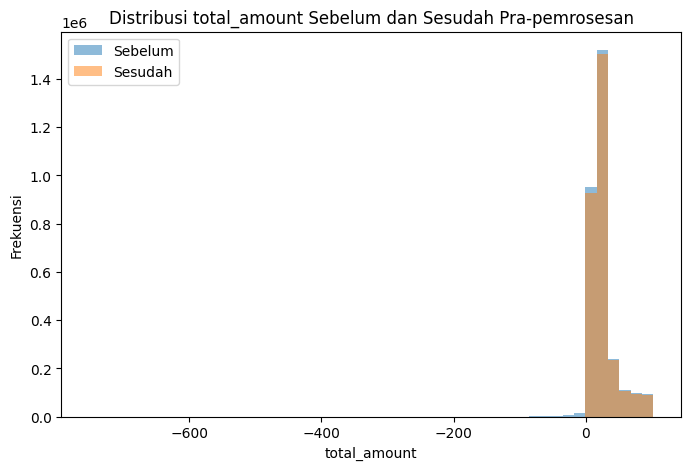

In [32]:
import matplotlib.pyplot as plt

x_min = min(trip["total_amount"].min(), bersih["total_amount"].min())
x_max = max(trip["total_amount"].quantile(0.99),
            bersih["total_amount"].quantile(0.99))

plt.figure(figsize=(8, 5))
plt.hist(
    trip["total_amount"].dropna(),
    bins=50,
    range=(x_min, x_max),
    alpha=0.5,
    label="Sebelum"
)
plt.hist(
    bersih["total_amount"].dropna(),
    bins=50,
    range=(x_min, x_max),
    alpha=0.5,
    label="Sesudah"
)

plt.xlabel("total_amount")
plt.ylabel("Frekuensi")
plt.title("Distribusi total_amount Sebelum dan Sesudah Pra-pemrosesan")
plt.legend()
plt.show()

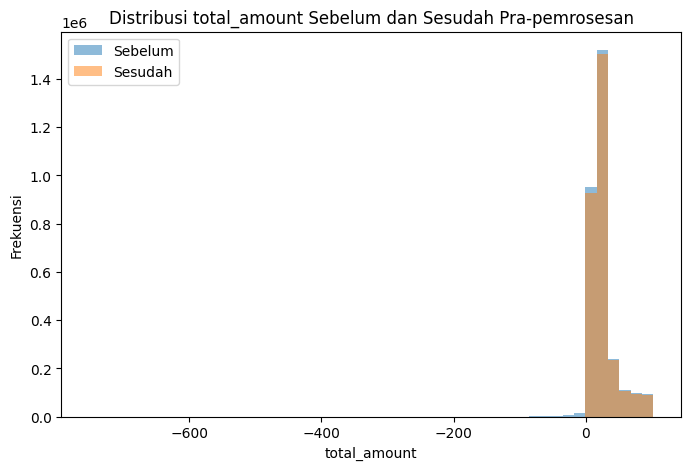

In [33]:
import matplotlib.pyplot as plt

x_min = min(trip["total_amount"].min(), bersih["total_amount"].min())
x_max = max(trip["total_amount"].quantile(0.99),
            bersih["total_amount"].quantile(0.99))

plt.figure(figsize=(8, 5))
plt.hist(
    trip["total_amount"].dropna(),
    bins=50,
    range=(x_min, x_max),
    alpha=0.5,
    label="Sebelum"
)
plt.hist(
    bersih["total_amount"].dropna(),
    bins=50,
    range=(x_min, x_max),
    alpha=0.5,
    label="Sesudah"
)

plt.xlabel("total_amount")
plt.ylabel("Frekuensi")
plt.title("Distribusi total_amount Sebelum dan Sesudah Pra-pemrosesan")
plt.legend()
plt.show()

studi kasus


In [35]:
tabel_analitik = (
    bersih
    .assign(
        jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h")
    )
    .groupby(
        ["borough_naik", "jam_mulai"],
        observed=True
    )
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_tarif_per_mil=("tarif_per_mil", "median"),
        rata_kecepatan=("kecepatan_mph", "median"),
        suhu_c=("suhu_c", "first"),
        hujan=("hujan", "max")
    )
    .reset_index()
)

tabel_analitik = tabel_analitik[
    tabel_analitik["jumlah_perjalanan"] >= 30
]

print(tabel_analitik.head())
print(tabel_analitik.shape)

    borough_naik           jam_mulai  jumlah_perjalanan  rata_tarif_per_mil  \
626     Brooklyn 2023-01-01 00:00:00                 86              6.9385   
627     Brooklyn 2023-01-01 01:00:00                220              6.9820   
628     Brooklyn 2023-01-01 02:00:00                256              6.6215   
629     Brooklyn 2023-01-01 03:00:00                175              6.6160   
630     Brooklyn 2023-01-01 04:00:00                 74              6.9120   

     rata_kecepatan  suhu_c  hujan  
626          14.550    10.9      1  
627          13.715    10.6      1  
628          15.445    10.6      0  
629          16.390    10.5      0  
630          14.635     9.8      0  
(2094, 7)


In [36]:
perbandingan_hujan = (
    tabel_analitik
    .groupby(
        ["borough_naik", "hujan"],
        observed=True
    )["rata_tarif_per_mil"]
    .median()
    .unstack()
)

print(perbandingan_hujan)

hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860


In [37]:
OUT_ANALITIK = os.path.join(
    DIR_KURASI,
    "tabel_analitik_pricing"
)

tabel_analitik.to_parquet(
    OUT_ANALITIK,
    index=False
)

print("Tabel analitik disimpan di:", OUT_ANALITIK)

Tabel analitik disimpan di: /content/lapisan_terkurasi/tabel_analitik_pricing


In [39]:
kamus = """
# Kamus Data Tabel Analitik Pricing

| Kolom | Tipe | Satuan | Sumber | Cara Penghitungan |
|---|---|---|---|---|
| borough_naik | object | - | Taxi Zone Lookup | Borough berdasarkan PULocationID |
| jam_mulai | datetime | jam | Data perjalanan | Waktu pickup dibulatkan ke jam |
| jumlah_perjalanan | int | perjalanan | Data perjalanan | Jumlah transaksi per borough per jam |
| rata_tarif_per_mil | float | uang/mil | Data perjalanan | Median tarif per mil |
| rata_kecepatan | float | mph | Data perjalanan | Median kecepatan |
| suhu_c | float | derajat C | Open-Meteo | Suhu pada jam tersebut |
| hujan | int | indikator | Open-Meteo | 1 jika hujan, 0 jika tidak |
"""

PATH_KAMUS = os.path.join(
    DIR_SIMPAN,
    "kamus_data.md"
)

with open(PATH_KAMUS, "w", encoding="utf-8") as f:
    f.write(kamus)

print("kamus_data.md disimpan di:", PATH_KAMUS)

kamus_data.md disimpan di: /content/drive/MyDrive/BigData/Praktikum3/kamus_data.md


latihan

In [40]:
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik + cache."""

    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            mulai = time.perf_counter()

            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()

                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)

            ukuran_mb = os.path.getsize(sementara) / 1024**2
            detik = time.perf_counter() - mulai
            kecepatan = ukuran_mb / detik

            if ukuran_mb == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan)

            print(
                f"berhasil: {os.path.basename(tujuan)} | "
                f"{ukuran_mb:.2f} MB | "
                f"{kecepatan:.2f} MB/detik"
            )

            return tujuan

        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(
                f"percobaan {i+1} gagal ({e}); "
                f"menunggu {jeda}s"
            )
            time.sleep(jeda)

    raise RuntimeError(
        f"gagal mengunduh setelah {percobaan} percobaan: {url}"
    )

In [41]:
unduh_aman(URL_TRIP, PATH_TRIP)
unduh_aman(URL_TRIP, PATH_TRIP)

cache ditemukan: yellow_tripdata_2023-01.parquet
cache ditemukan: yellow_tripdata_2023-01.parquet


'/content/lapisan_mentah/yellow_tripdata_2023-01.parquet'

In [42]:
aturan_tambahan = {
    "validitas: tip_amount >= 0":
        trip["tip_amount"] >= 0,

    "konsistensi: tip_amount <= total_amount":
        trip["tip_amount"] <= trip["total_amount"],
}

laporan_tambahan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3)
    }
    for nama, mask in aturan_tambahan.items()
])

print(laporan_tambahan)

                                    aturan    lulus  gagal  persen_gagal
0               validitas: tip_amount >= 0  3066540    225         0.007
1  konsistensi: tip_amount <= total_amount  3041561  25204         0.822


In [44]:
bersih_tujuan = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(
        columns={
            "Borough": "borough_tujuan",
            "Zone": "zona_tujuan"
        }
    ),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

bersih_tujuan = bersih_tujuan.drop(
    columns="LocationID"
)

print(bersih_tujuan.head())

  tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  trip_distance  \
0  2023-01-01 00:32:10   2023-01-01 00:40:36              1.0           0.97   
1  2023-01-01 00:55:08   2023-01-01 01:01:27              1.0           1.10   
2  2023-01-01 00:25:04   2023-01-01 00:37:49              1.0           2.51   
3  2023-01-01 00:03:48   2023-01-01 00:13:25              0.0           1.90   
4  2023-01-01 00:10:29   2023-01-01 00:21:19              1.0           1.43   

   PULocationID  DOLocationID  payment_type  fare_amount  tip_amount  \
0           161           141             2          9.3        0.00   
1            43           237             1          7.9        4.00   
2            48           238             1         14.9       15.00   
3           138             7             1         12.1        0.00   
4           107            79             1         11.4        3.28   

   total_amount  ...  jam_mulai  suhu_c  hujan_mm  hari_minggu  akhir_pekan  \
0      

In [45]:
top10_pasangan = (
    bersih_tujuan
    .groupby(
        ["borough_naik", "borough_tujuan"],
        dropna=False
    )
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values(
        "jumlah_perjalanan",
        ascending=False
    )
    .head(10)
)

print(top10_pasangan)

   borough_naik borough_tujuan  jumlah_perjalanan
25    Manhattan      Manhattan            2491566
33       Queens      Manhattan             155261
26    Manhattan         Queens              82354
23    Manhattan       Brooklyn              62986
34       Queens         Queens              59146
31       Queens       Brooklyn              42187
48      Unknown      Manhattan              18432
51      Unknown        Unknown              13562
22    Manhattan          Bronx               8865
9      Brooklyn       Brooklyn               7910


In [46]:
from sklearn.preprocessing import MinMaxScaler

skala_minmax = MinMaxScaler()

latih_minmax = skala_minmax.fit_transform(
    latih[FITUR_NUM]
)

uji_minmax = skala_minmax.transform(
    uji[FITUR_NUM]
)

print("Minimum data latih:",
      latih_minmax.min(axis=0).round(3))

print("Maksimum data latih:",
      latih_minmax.max(axis=0).round(3))

print("Minimum data uji:",
      uji_minmax.min(axis=0).round(3))

print("Maksimum data uji:",
      uji_minmax.max(axis=0).round(3))

Minimum data latih: [0. 0. 0.]
Maksimum data latih: [1. 1. 1.]
Minimum data uji: [0. 0. 0.]
Maksimum data uji: [1.   0.91 1.  ]


In [48]:
zona_error = zona.copy()

# Gandakan satu baris
zona_error = pd.concat(
    [zona_error, zona_error.iloc[[0]]],
    ignore_index=True
)

print("LocationID unik?",
      zona_error["LocationID"].is_unique)

try:
    hasil_error = bersih.merge(
        zona_error[["LocationID", "Borough", "Zone"]],
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )
except Exception as e:
    print("ERROR YANG MUNCUL:")
    print(type(e).__name__)
    print(e)

# Kembalikan ke tabel asli
zona = zona.drop_duplicates(
    subset=["LocationID"]
).reset_index(drop=True)

print("Setelah diperbaiki:")
print("LocationID unik?", zona["LocationID"].is_unique)

LocationID unik? False
ERROR YANG MUNCUL:
MergeError
Merge keys are not unique in right dataset; not a many-to-one merge
Setelah diperbaiki:
LocationID unik? True


In [57]:
OUT_INCREMENTAL = os.path.join(
    DIR_KURASI,
    "trips_incremental"
)
os.makedirs(OUT_INCREMENTAL, exist_ok=True)

def pipeline_inkremental(bulan, tahun=2023):
    marker = os.path.join(
        OUT_INCREMENTAL,
        f"bulan_{tahun}_{bulan:02d}.done"
    )
    if os.path.exists(marker):
        print(
            f"Bulan {tahun}-{bulan:02d} "
            "sudah diproses. Tidak ada berkas baru."
        )
        return None
    mulai = pd.Timestamp(
        year=tahun,
        month=bulan,
        day=1
    )
    if bulan == 12:
        selesai = pd.Timestamp(
            year=tahun + 1,
            month=1,
            day=1
        ) - pd.Timedelta(days=1)
    else:
        selesai = pd.Timestamp(
            year=tahun,
            month=bulan + 1,
            day=1
        ) - pd.Timedelta(days=1)

    awal_str = mulai.strftime("%Y-%m-%d")
    akhir_str = selesai.strftime("%Y-%m-%d")

    url_trip = (
        "https://d37ci6vzurychx.cloudfront.net/"
        f"trip-data/yellow_tripdata_{tahun}-{bulan:02d}.parquet"
    )

    path_trip = os.path.join(
        DIR_MENTAH,
        f"yellow_tripdata_{tahun}-{bulan:02d}.parquet"
    )

    unduh_aman(url_trip, path_trip)

    cuaca_bulan = ambil_cuaca(
        awal_str,
        akhir_str
    )

    cuaca_bulan["time"] = pd.to_datetime(
        cuaca_bulan["time"]
    )

    cuaca_bulan = cuaca_bulan.rename(
        columns={
            "time": "jam_mulai",
            "temperature_2m": "suhu_c",
            "precipitation": "hujan_mm"
        }
    )
    hasil_bulan = pipeline(
        path_trip,
        PATH_ZONA,
        cuaca_bulan,
        tarif_referensi
    )

    hasil_bulan["bulan"] = (
        f"{tahun}-{bulan:02d}"
    )
    hasil_bulan.to_parquet(
        os.path.join(
            OUT_INCREMENTAL,
            f"bulan={tahun}-{bulan:02d}"
        ),
        index=False
    )

    with open(marker, "w") as f:
        f.write("selesai")

    print(
        f"Bulan {tahun}-{bulan:02d} berhasil diproses."
    )
    return hasil_bulan

In [52]:
hasil_jan = pipeline_inkremental(1, 2023)
hasil_jan_ulang = pipeline_inkremental(1, 2023)

cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
Bulan 2023-01 berhasil diproses.
Bulan 2023-01 sudah diproses. Tidak ada berkas baru.


tugas

Pipeline Dua Bulan

Pada tugas ini pipeline dijalankan untuk dua bulan yang berbeda, yaitu Januari dan Juli 2023. Hasil kedua bulan disimpan pada direktori keluaran yang sama. Setelah itu dilakukan pemeriksaan terhadap kunci perjalanan untuk memastikan tidak terdapat duplikasi antarbulan.

In [58]:
# Direktori keluaran untuk data dua bulan
OUT_DUA_BULAN = "/content/lapisan_terkurasi/trips_dua_bulan"

os.makedirs(OUT_DUA_BULAN, exist_ok=True)

In [59]:
hasil_januari = pipeline_inkremental(1, 2023)
hasil_juli = pipeline_inkremental(7, 2023)

Bulan 2023-01 sudah diproses. Tidak ada berkas baru.
berhasil: yellow_tripdata_2023-07.parquet | 46.12 MB | 85.99 MB/detik
Validasi lulus: 2,817,657 baris x 17 kolom
Bulan 2023-07 berhasil diproses.


In [60]:
KUNCI = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount"
]

gabungan = pd.concat(
    [hasil_januari, hasil_juli],
    ignore_index=True
)

jumlah_sebelum = len(gabungan)
jumlah_sesudah = len(gabungan.drop_duplicates(subset=KUNCI))

print("Jumlah baris sebelum pemeriksaan:", jumlah_sebelum)
print("Jumlah baris setelah hapus duplikat:", jumlah_sesudah)
print("Duplikasi antarbulan:", jumlah_sebelum - jumlah_sesudah)

Jumlah baris sebelum pemeriksaan: 2817657
Jumlah baris setelah hapus duplikat: 2817657
Duplikasi antarbulan: 0


In [62]:
def buat_laporan_kualitas(df, awal, akhir):
    zona_sah = set(zona["LocationID"])

    aturan = {
        "kelengkapan: passenger_count ada":
            df["passenger_count"].notna(),

        "keunikan: baris tidak duplikat":
            ~df.duplicated(),

        "validitas: jarak 0-100 mil":
            df["trip_distance"].between(0.01, 100),

        "validitas: total_amount > 0":
            df["total_amount"] > 0,

        "validitas: PULocationID dikenal":
            df["PULocationID"].isin(zona_sah),

        "konsistensi: durasi 1-180 menit":
            df["durasi_menit"].between(1, 180),

        "konsistensi: total >= fare":
            df["total_amount"] >= df["fare_amount"],

        "ketepatan waktu":
            df["tpep_pickup_datetime"].between(
                pd.Timestamp(awal),
                pd.Timestamp(akhir)
            )
    }

    return pd.DataFrame([
        {
            "aturan": nama,
            "lulus": int(mask.sum()),
            "gagal": int((~mask).sum()),
            "persen_gagal": round(100 * (~mask).mean(), 3)
        }
        for nama, mask in aturan.items()
    ])

In [66]:
import os

marker_januari = os.path.join(
    OUT_INCREMENTAL,
    "bulan_2023_01.done"
)

print("Marker Januari ada:", os.path.exists(marker_januari))

Marker Januari ada: True


In [67]:
if os.path.exists(marker_januari):
    os.remove(marker_januari)
    print("Marker Januari dihapus.")

Marker Januari dihapus.


In [68]:
hasil_januari = pipeline_inkremental(1, 2023)

cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
Bulan 2023-01 berhasil diproses.


In [69]:
print(type(hasil_januari))
print(hasil_januari.shape)

<class 'pandas.core.frame.DataFrame'>
(2986910, 18)


In [70]:
laporan_januari = buat_laporan_kualitas(
    hasil_januari,
    "2023-01-01",
    "2023-01-31 23:59:59"
)

laporan_januari["bulan"] = "Januari 2023"

laporan_januari

,aturan,lulus,gagal,persen_gagal,bulan
0,kelengkapan: passenger_count ada,2986910,0,0.000,Januari 2023
1,keunikan: baris tidak duplikat,2986910,0,0.000,Januari 2023
2,validitas: jarak 0-100 mil,2986910,0,0.000,Januari 2023
3,validitas: total_amount > 0,2986910,0,0.000,Januari 2023
4,validitas: PULocationID dikenal,2986910,0,0.000,Januari 2023
5,konsistensi: durasi 1-180 menit,2986910,0,0.000,Januari 2023
6,konsistensi: total >= fare,2986908,2,0.000,Januari 2023
7,ketepatan waktu,2986873,37,0.001,Januari 2023


In [71]:
laporan_juli = buat_laporan_kualitas(
    hasil_juli,
    "2023-07-01",
    "2023-07-31 23:59:59"
)

laporan_juli["bulan"] = "Juli 2023"

laporan_juli

,aturan,lulus,gagal,persen_gagal,bulan
0,kelengkapan: passenger_count ada,2817657,0,0.000,Juli 2023
1,keunikan: baris tidak duplikat,2817657,0,0.000,Juli 2023
2,validitas: jarak 0-100 mil,2817657,0,0.000,Juli 2023
3,validitas: total_amount > 0,2817657,0,0.000,Juli 2023
4,validitas: PULocationID dikenal,2817657,0,0.000,Juli 2023
5,konsistensi: durasi 1-180 menit,2817657,0,0.000,Juli 2023
6,konsistensi: total >= fare,2817657,0,0.000,Juli 2023
7,ketepatan waktu,2817607,50,0.002,Juli 2023


Laporan Kualitas Komparatif

Pada tugas ini laporan kualitas dari dua bulan dibandingkan dalam satu tabel. Perbandingan dilakukan terhadap persentase data yang gagal pada setiap aturan kualitas. Aturan dengan perubahan persentase yang paling besar kemudian dianalisis untuk mengetahui kemungkinan penyebabnya.

In [72]:
laporan_januari = laporan_januari.copy()
laporan_juli = laporan_juli.copy()

laporan_januari["bulan"] = "Januari 2023"
laporan_juli["bulan"] = "Juli 2023"

In [74]:
perbandingan = laporan_januari[
    ["aturan", "lulus", "gagal", "persen_gagal"]
].merge(
    laporan_juli[
        ["aturan", "lulus", "gagal", "persen_gagal"]
    ],
    on="aturan",
    suffixes=("_januari", "_juli")
)

perbandingan["perubahan_persen_gagal"] = (
    perbandingan["persen_gagal_juli"]
    - perbandingan["persen_gagal_januari"]
)

perbandingan["perubahan_absolut"] = (
    perbandingan["perubahan_persen_gagal"].abs()
)

perbandingan.sort_values(
    "perubahan_absolut",
    ascending=False
)

,aturan,lulus_januari,gagal_januari,persen_gagal_januari,lulus_juli,gagal_juli,persen_gagal_juli,perubahan_persen_gagal,perubahan_absolut
7,ketepatan waktu,2986873,37,0.001,2817607,50,0.002,0.001,0.001
0,kelengkapan: passenger_count ada,2986910,0,0.000,2817657,0,0.000,0.000,0.000
2,validitas: jarak 0-100 mil,2986910,0,0.000,2817657,0,0.000,0.000,0.000
1,keunikan: baris tidak duplikat,2986910,0,0.000,2817657,0,0.000,0.000,0.000
3,validitas: total_amount > 0,2986910,0,0.000,2817657,0,0.000,0.000,0.000
4,validitas: PULocationID dikenal,2986910,0,0.000,2817657,0,0.000,0.000,0.000
5,konsistensi: durasi 1-180 menit,2986910,0,0.000,2817657,0,0.000,0.000,0.000
6,konsistensi: total >= fare,2986908,2,0.000,2817657,0,0.000,0.000,0.000


Sumber Keempat

Pada tugas ini ditambahkan satu sumber data eksternal berupa data hari libur nasional dari API publik. Data tersebut digunakan untuk memberikan informasi tambahan berdasarkan tanggal perjalanan. Data API kemudian diubah menjadi DataFrame dan diintegrasikan dengan dataset perjalanan berdasarkan tanggal.

In [76]:
import requests
import pandas as pd

URL_HARI_LIBUR = "https://date.nager.at/api/v3/PublicHolidays/2023/US"

response = requests.get(URL_HARI_LIBUR)

if response.status_code == 200:
    hari_libur = pd.DataFrame(response.json())
    print("Data hari libur berhasil diambil.")
    print("Jumlah data:", len(hari_libur))
    print(hari_libur[["date", "localName"]].head())
else:
    raise Exception(
        f"Gagal mengambil data hari libur. Status code: {response.status_code}"
    )

Data hari libur berhasil diambil.
Jumlah data: 17
         date                    localName
0  2023-01-02               New Year's Day
1  2023-01-16  Martin Luther King, Jr. Day
2  2023-02-12           Lincoln's Birthday
3  2023-02-20        Washington's Birthday
4  2023-04-07                  Good Friday


In [77]:
hari_libur["date"] = pd.to_datetime(
    hari_libur["date"]
).dt.date

hasil_januari["tanggal"] = pd.to_datetime(
    hasil_januari["tpep_pickup_datetime"]
).dt.date

hasil_januari = hasil_januari.merge(
    hari_libur[["date", "name"]],
    left_on="tanggal",
    right_on="date",
    how="left"
)

hasil_januari["is_holiday"] = (
    hasil_januari["name"].notna()
).astype(int)

hasil_januari = hasil_januari.drop(
    columns=["date", "name"]
)

In [78]:
hasil_januari[
    ["tanggal", "is_holiday"]
].head()

,tanggal,is_holiday
0,2023-01-01,0
1,2023-01-01,0
2,2023-01-01,0
3,2023-01-01,0
4,2023-01-01,0


Kamus Data

Pada tugas ini dibuat kamus data yang mendokumentasikan seluruh kolom pada dataset akhir. Informasi yang dicatat meliputi nama kolom, tipe data, satuan, sumber data, aturan validitas, dan cara penanganan nilai hilang.

In [79]:
kamus_data = """
# Kamus Data Dataset Akhir

| Nama | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |
|---|---|---|---|---|---|
| tpep_pickup_datetime | datetime | waktu | Data trip | waktu penjemputan valid | Tidak diisi jika tidak tersedia |
| tpep_dropoff_datetime | datetime | waktu | Data trip | waktu pengantaran valid | Tidak diisi jika tidak tersedia |
| passenger_count | float64 | penumpang | Data trip | nilai numerik | Median kelompok jam |
| trip_distance | float64 | mil | Data trip | 0.01–100 | Baris di luar rentang difilter |
| PULocationID | int64 | ID zona | Data trip | harus terdapat pada tabel zona | Baris dengan ID tidak valid difilter/join |
| DOLocationID | int64 | ID zona | Data trip | ID zona valid | Mengikuti data sumber |
| payment_type | int64 | kode | Data trip | kode pembayaran valid | Mengikuti data sumber |
| fare_amount | float64 | mata uang | Data trip | nilai numerik | Mengikuti data sumber |
| tip_amount | float64 | mata uang | Data trip | nilai numerik | Mengikuti data sumber |
| total_amount | float64 | mata uang | Data trip | > 0 | Baris dengan nilai tidak valid difilter |
| durasi_menit | float64 | menit | Hasil perhitungan | 1–180 | Baris di luar rentang difilter |
| borough_naik | object | kategori | Tabel zona | borough sesuai LocationID | Hasil left join |
| nama_pembayaran | object | kategori | SQLite | sesuai payment_type | Hasil left join |
| suhu_c | float64 | °C | API cuaca | nilai numerik | Mengikuti hasil join cuaca |
| hujan_mm | float64 | mm | API cuaca | nilai >= 0 | Mengikuti hasil join cuaca |
| is_holiday | int64 | indikator | API hari libur | 0 atau 1 | Diisi 0 jika bukan hari libur |
"""

with open("/content/kamus_data.md", "w", encoding="utf-8") as f:
    f.write(kamus_data)

print("kamus_data.md berhasil dibuat")

kamus_data.md berhasil dibuat
